In [22]:
import pandas as pd

ml_table = pd.read_csv("../data/ML_Table_Labeled_2.csv")

print("Shape:", ml_table.shape)
display(ml_table.head())

Shape: (99441, 82)


,order_id,customer_id,order_status,customer_zip_code_prefix,customer_state,customer_lat,customer_lng,purchase_time_min,purchase_time_max,purchase_time_median,...,payment_type_voucher,review_count,review_creation_min,review_creation_max,review_creation_median,review_answer_min,review_answer_max,review_answer_median,delay_days,delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,3149,SP,-23.576170,-46.587276,2017-10-02 10:56:33,2017-10-02 10:56:33,2017-10-02 10:56:33,...,1.0,1.0,2017-10-11,2017-10-11,2017-10-11 00:00:00,2017-10-12 03:43:48,2017-10-12 03:43:48,2017-10-12 03:43:48.000,-7.107488,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,47813,BA,-12.126651,-45.008162,2018-07-24 20:41:37,2018-07-24 20:41:37,2018-07-24 20:41:37,...,0.0,1.0,2018-08-08,2018-08-08,2018-08-08 00:00:00,2018-08-08 18:37:50,2018-08-08 18:37:50,2018-08-08 18:37:50.000,-5.355729,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,75265,GO,-16.744472,-48.514624,2018-08-08 08:38:49,2018-08-08 08:38:49,2018-08-08 08:38:49,...,0.0,1.0,2018-08-18,2018-08-18,2018-08-18 00:00:00,2018-08-22 19:07:58,2018-08-22 19:07:58,2018-08-22 19:07:58.000,-17.245498,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,59296,RN,-5.774611,-35.273916,2017-11-18 19:28:06,2017-11-18 19:28:06,2017-11-18 19:28:06,...,0.0,1.0,2017-12-03,2017-12-03,2017-12-03 00:00:00,2017-12-05 19:21:58,2017-12-05 19:21:58,2017-12-05 19:21:58.000,-12.980069,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,9195,SP,-23.675316,-46.515116,2018-02-13 21:18:39,2018-02-13 21:18:39,2018-02-13 21:18:39,...,0.0,1.0,2018-02-17,2018-02-17,2018-02-17 00:00:00,2018-02-18 13:02:51,2018-02-18 13:02:51,2018-02-18 13:02:51.000,-9.238171,0.0


In [23]:
ml_table.columns

Index(['order_id', 'customer_id', 'order_status', 'customer_zip_code_prefix',
       'customer_state', 'customer_lat', 'customer_lng', 'purchase_time_min',
       'purchase_time_max', 'purchase_time_median', 'approval_time_min',
       'approval_time_max', 'approval_time_median', 'carrier_date_min',
       'carrier_date_max', 'carrier_date_median', 'delivered_date_min',
       'delivered_date_max', 'delivered_date_median',
       'estimated_delivery_date_min', 'estimated_delivery_date_max',
       'estimated_delivery_date_median', 'customer_city', 'item_count',
       'unique_products', 'seller_count', 'total_price', 'min_price',
       'max_price', 'mean_price', 'median_price', 'total_freight',
       'min_freight', 'max_freight', 'mean_freight', 'median_freight',
       'shipping_limit_min', 'shipping_limit_max', 'shipping_limit_median',
       'unique_seller_states', 'seller_city', 'sellers_same_customer_state',
       'unique_category_count', 'total_weight_g', 'min_weight_g',
     

In [24]:
print("Columns:")
print(ml_table.columns.tolist())

print("\nTarget:")
print(ml_table["delayed"].value_counts(dropna=False))

Columns:
['order_id', 'customer_id', 'order_status', 'customer_zip_code_prefix', 'customer_state', 'customer_lat', 'customer_lng', 'purchase_time_min', 'purchase_time_max', 'purchase_time_median', 'approval_time_min', 'approval_time_max', 'approval_time_median', 'carrier_date_min', 'carrier_date_max', 'carrier_date_median', 'delivered_date_min', 'delivered_date_max', 'delivered_date_median', 'estimated_delivery_date_min', 'estimated_delivery_date_max', 'estimated_delivery_date_median', 'customer_city', 'item_count', 'unique_products', 'seller_count', 'total_price', 'min_price', 'max_price', 'mean_price', 'median_price', 'total_freight', 'min_freight', 'max_freight', 'mean_freight', 'median_freight', 'shipping_limit_min', 'shipping_limit_max', 'shipping_limit_median', 'unique_seller_states', 'seller_city', 'sellers_same_customer_state', 'unique_category_count', 'total_weight_g', 'min_weight_g', 'max_weight_g', 'mean_weight_g', 'median_weight_g', 'total_volume_cm3', 'min_volume_cm3', 'ma

In [25]:
print("=" * 70)
print("DELAY_DAYS")
print("=" * 70)
print("Missing:", ml_table["delay_days"].isna().sum())
print("Unique:", ml_table["delay_days"].nunique())
print("\nStatistics:")
print(ml_table["delay_days"].describe())
print("\nSample values:")
print(ml_table["delay_days"].head(20).tolist())

print("\n" + "=" * 70)
print("DELAYED LABEL")
print("=" * 70)
print("Missing:", ml_table["delayed"].isna().sum())
print("Unique:", ml_table["delayed"].nunique())
print("\nValue counts:")
print(ml_table["delayed"].value_counts(dropna=False))

print("\nClass distribution (%):")
print((ml_table["delayed"].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\n" + "=" * 70)
print("CLASS BALANCE")
print("=" * 70)

counts = ml_table["delayed"].value_counts()
if 0 in counts and 1 in counts:
    majority = counts.max()
    minority = counts.min()
    imbalance_ratio = majority / minority
    print(f"On Time (0): {counts[0]:,}")
    print(f"Late (1):    {counts[1]:,}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

DELAY_DAYS
Missing: 2965
Unique: 91915

Statistics:
count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delay_days, dtype: float64

Sample values:
[-7.107488425925926, -5.355729166666666, -17.245497685185185, -12.980069444444444, -9.238171296296295, -5.543113425925926, nan, -11.461215277777775, -31.41099537037037, -6.281597222222223, -8.52880787037037, -19.41333333333333, -28.495925925925928, -8.338599537037037, -8.01636574074074, -12.35101851851852, -16.931261574074075, -20.057916666666667, -13.230555555555556, -14.068055555555556]

DELAYED LABEL
Missing: 2965
Unique: 2

Value counts:
delayed
0.0    88649
1.0     7827
NaN     2965
Name: count, dtype: int64

Class distribution (%):
delayed
0.0    89.15
1.0     7.87
NaN     2.98
Name: proportion, dtype: float64

CLASS BALANCE
On Time (0): 88,649
Late (1):    7,827
Imbalance ratio: 11.33:1


# Time-based delay check

In [26]:
late = ml_table[ml_table["delayed"] == 1].copy()

bins = [0, 7, 14, 21, 30, 60, 90, 180, 365, float("inf")]
labels = [
    "1 week or less",
    "1–2 weeks",
    "2–3 weeks",
    "3–4 weeks",
    "1–2 months",
    "2–3 months",
    "3–6 months",
    "6–12 months",
    "More than 1 year"
]

late["delay_period"] = pd.cut(
    late["delay_days"],
    bins=bins,
    labels=labels,
    right=True
)

print("Late orders:", len(late))

print("\nDelay distribution among late orders:")
print(late["delay_period"].value_counts().sort_index())

print("\nPercentage among late orders:")
print(late["delay_period"].value_counts(normalize=True).sort_index().mul(100).round(2))

Late orders: 7827

Delay distribution among late orders:
delay_period
1 week or less      4481
1–2 weeks           1791
2–3 weeks            760
3–4 weeks            435
1–2 months           276
2–3 months            37
3–6 months            45
6–12 months            2
More than 1 year       0
Name: count, dtype: int64

Percentage among late orders:
delay_period
1 week or less      57.25
1–2 weeks           22.88
2–3 weeks            9.71
3–4 weeks            5.56
1–2 months           3.53
2–3 months           0.47
3–6 months           0.57
6–12 months          0.03
More than 1 year     0.00
Name: proportion, dtype: float64


In [27]:
import pandas as pd

df = ml_table.copy()

date_col = "purchase_time_min"

# Convert purchase date
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

print("=" * 80)
print("TEMPORAL DATA CHECK")
print("=" * 80)

print("\nDate range:")
print("Minimum:", df[date_col].min())
print("Maximum:", df[date_col].max())

print("\nMissing purchase dates:")
print(df[date_col].isna().sum())

print("\nRows with missing delayed label:")
print(df["delayed"].isna().sum())

TEMPORAL DATA CHECK

Date range:
Minimum: 2016-09-04 21:15:19
Maximum: 2018-10-17 17:30:18

Missing purchase dates:
0

Rows with missing delayed label:
2965


In [28]:
df["year"] = df[date_col].dt.year

year_summary = (
    df.groupby("year")
    .agg(
        orders=("order_id", "count"),
        on_time=("delayed", lambda x: (x == 0).sum()),
        delayed=("delayed", lambda x: (x == 1).sum())
    )
)

year_summary["on_time_%"] = (
    year_summary["on_time"] / year_summary["orders"] * 100
).round(2)

year_summary["delayed_%"] = (
    year_summary["delayed"] / year_summary["orders"] * 100
).round(2)

display(year_summary)


,orders,on_time,delayed,on_time_%,delayed_%
year,,,,,
2016,329,268,4,81.46,1.22
2017,45101,40548,2878,89.90,6.38
2018,54011,47833,4945,88.56,9.16


In [29]:
df["month"] = df[date_col].dt.month

month_summary = (
    df.groupby("month")
    .agg(
        orders=("order_id", "count"),
        on_time=("delayed", lambda x: (x == 0).sum()),
        delayed=("delayed", lambda x: (x == 1).sum())
    )
)

month_summary["on_time_%"] = (
    month_summary["on_time"] / month_summary["orders"] * 100
).round(2)

month_summary["delayed_%"] = (
    month_summary["delayed"] / month_summary["orders"] * 100
).round(2)

display(month_summary)

,orders,on_time,delayed,on_time_%,delayed_%
month,,,,,
1,8069,7332,487,90.87,6.04
2,8508,7107,1102,83.53,12.95
3,9893,7911,1638,79.97,16.56
4,9343,8559,542,91.61,5.80
5,10573,9610,684,90.89,6.47
6,9412,9027,204,95.91,2.17
7,10318,9619,409,93.23,3.96
8,10843,9745,799,89.87,7.37
9,4305,3934,217,91.38,5.04


In [30]:
df["year_month"] = df[date_col].dt.to_period("M").astype(str)

monthly_summary = (
    df.groupby("year_month")
    .agg(
        orders=("order_id", "count"),
        on_time=("delayed", lambda x: (x == 0).sum()),
        delayed=("delayed", lambda x: (x == 1).sum())
    )
)

monthly_summary["on_time_%"] = (
    monthly_summary["on_time"] / monthly_summary["orders"] * 100
).round(2)

monthly_summary["delayed_%"] = (
    monthly_summary["delayed"] / monthly_summary["orders"] * 100
).round(2)

display(monthly_summary)

,orders,on_time,delayed,on_time_%,delayed_%
year_month,,,,,
2016-09,4,0,1,0.00,25.00
2016-10,324,267,3,82.41,0.93
2016-12,1,1,0,100.00,0.00
2017-01,800,727,23,90.88,2.88
2017-02,1780,1600,53,89.89,2.98
2017-03,2682,2404,142,89.63,5.29
2017-04,2404,2122,181,88.27,7.53
2017-05,3700,3417,128,92.35,3.46
2017-06,3245,3014,121,92.88,3.73


In [31]:
display(
    monthly_summary[["orders", "delayed", "delayed_%"]]
)

,orders,delayed,delayed_%
year_month,,,
2016-09,4,1,25.00
2016-10,324,3,0.93
2016-12,1,0,0.00
2017-01,800,23,2.88
2017-02,1780,53,2.98
2017-03,2682,142,5.29
2017-04,2404,181,7.53
2017-05,3700,128,3.46
2017-06,3245,121,3.73


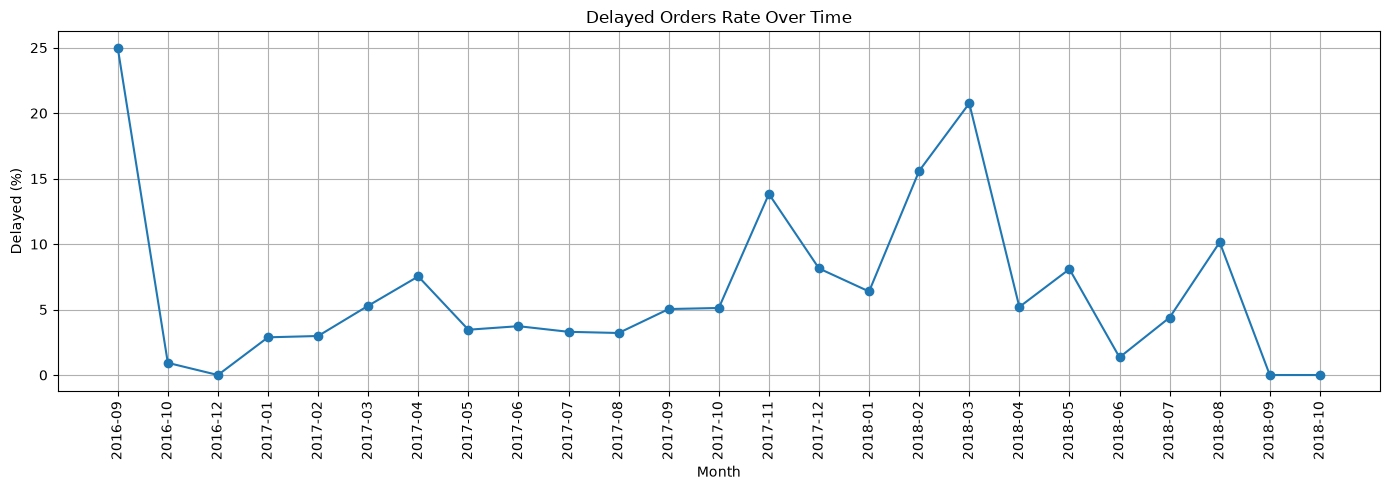

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_summary.index,
    monthly_summary["delayed_%"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Delayed (%)")
plt.title("Delayed Orders Rate Over Time")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

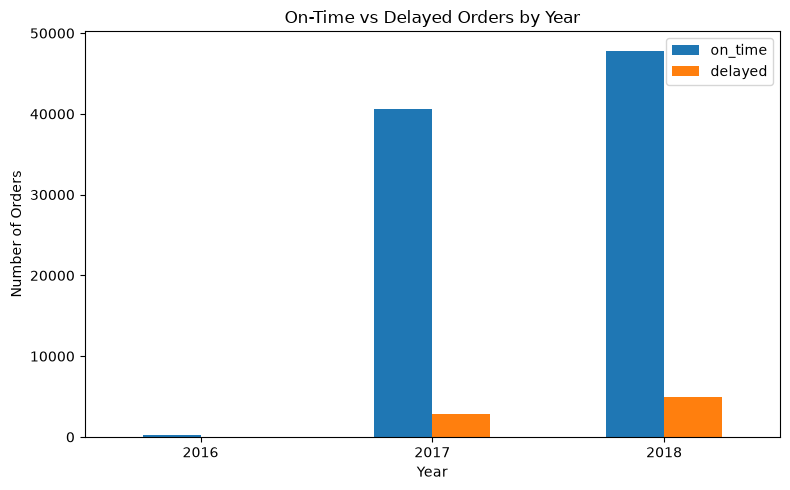

In [33]:
year_summary[["on_time", "delayed"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.title("On-Time vs Delayed Orders by Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# NA in Target Column

In [34]:
! pip install scikit-learn

In [35]:
import pandas as pd

ml_table = pd.read_csv("../data/ML_Table_Labeled_2.csv")

# ============================================================
# DATASET OVERVIEW
# ============================================================

overview = pd.Series({
    "Rows": len(ml_table),
    "Columns": len(ml_table.columns),
    "Missing target": ml_table["delayed"].isna().sum(),
    "On Time (0)": (ml_table["delayed"] == 0).sum(),
    "Delayed (1)": (ml_table["delayed"] == 1).sum()
})

display(overview.to_frame("Value"))

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_summary = (
    ml_table["delayed"]
    .value_counts(dropna=False)
    .rename(index={0: "On Time", 1: "Delayed"})
    .to_frame("Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(ml_table) * 100
).round(2)

display(target_summary)

# ============================================================
# MISSING VALUES
# ============================================================

missing_summary = pd.DataFrame({
    "Missing": ml_table.isna().sum()
})

missing_summary["Percentage"] = (
    missing_summary["Missing"] / len(ml_table) * 100
).round(2)

missing_summary = (
    missing_summary[missing_summary["Missing"] > 0]
    .sort_values("Missing", ascending=False)
)

display(missing_summary)

# ============================================================
# MISSING TARGET OVER TIME
# ============================================================

ml_table["purchase_time_min"] = pd.to_datetime(
    ml_table["purchase_time_min"],
    errors="coerce"
)

ml_table["year"] = ml_table["purchase_time_min"].dt.year

missing_by_year = (
    ml_table.groupby("year")["delayed"]
    .agg(
        total_orders="size",
        missing_target=lambda x: x.isna().sum()
    )
)

missing_by_year["missing_%"] = (missing_by_year["missing_target"]
/ missing_by_year["total_orders"]
    * 100
).round(2)

display(missing_by_year)

# ============================================================
# MISSING TARGET — SAMPLE
# ============================================================

missing_target_rows = ml_table[
    ml_table["delayed"].isna()
][[
    "order_id",
    "order_status",
    "purchase_time_min",
    "delivered_date_min",
    "estimated_delivery_date_min",
    "delay_days"
]]

print(f"Rows with missing target: {len(missing_target_rows):,}")

display(missing_target_rows.head(5))

,Value
Rows,99441
Columns,82
Missing target,2965
On Time (0),88649
Delayed (1),7827


,Count,Percentage
delayed,,
On Time,88649,89.15
Delayed,7827,7.87
NaN,2965,2.98


,Missing,Percentage
delivered_date_min,2965,2.98
delayed,2965,2.98
delay_days,2965,2.98
delivered_date_median,2965,2.98
delivered_date_max,2965,2.98
...,...,...
payment_type_not_defined,1,0.00
max_installments,1,0.00
payment_type_boleto,1,0.00
median_payment,1,0.00


,total_orders,missing_target,missing_%
year,,,
2016,329,57,17.33
2017,45101,1675,3.71
2018,54011,1233,2.28


Rows with missing target: 2,965


,order_id,order_status,purchase_time_min,delivered_date_min,estimated_delivery_date_min,delay_days
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaN,2017-05-09,NaN
44,ee64d42b8cf066f35eac1cf57de1aa85,shipped,2018-06-04 16:44:48,NaN,2018-06-28,NaN
103,0760a852e4e9d89eb77bf631eaaf1c84,invoiced,2018-08-03 17:44:42,NaN,2018-08-21,NaN
128,15bed8e2fec7fdbadb186b57c46c92f2,processing,2017-09-03 14:22:03,NaN,2017-10-03,NaN
154,6942b8da583c2f9957e990d028607019,shipped,2018-01-10 11:33:07,NaN,2018-02-07,NaN


In [36]:
missing_target = ml_table[ml_table["delayed"].isna()].copy()

print("=" * 70)
print("MISSING TARGET — ORDER STATUS")
print("=" * 70)

print("\nCounts:")
print(missing_target["order_status"].value_counts(dropna=False))

print("\nPercentages:")
print(
    missing_target["order_status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

MISSING TARGET — ORDER STATUS

Counts:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Percentages:
order_status
shipped        37.34
canceled       20.88
unavailable    20.54
invoiced       10.59
processing     10.15
delivered       0.27
created         0.17
approved        0.07
Name: proportion, dtype: float64


In [37]:
print("\n" + "=" * 70)
print("ORDER STATUS vs DELIVERY DATE")
print("=" * 70)

status_delivery = pd.crosstab(
    ml_table["order_status"],
    ml_table["delivered_date_min"].isna(),
    normalize="index"
).mul(100).round(2)

status_delivery.columns = [
    "Delivery Available",
    "Delivery Missing"
]

display(status_delivery)


ORDER STATUS vs DELIVERY DATE


,Delivery Available,Delivery Missing
order_status,,
approved,0.00,100.00
canceled,0.96,99.04
created,0.00,100.00
delivered,99.99,0.01
invoiced,0.00,100.00
processing,0.00,100.00
shipped,0.00,100.00
unavailable,0.00,100.00


In [38]:
# The missing target is not random. It is strongly associated with order_status
# and the availability of the delivery date:
# - Almost all "shipped" orders have no customer delivery date.
# - "invoiced", "processing", "created", and "approved" orders have no delivery date.
# - 99.04% of "canceled" orders have no delivery date.
# - In contrast, 99.99% of "delivered" orders have a delivery date.
#
# Therefore, the missing target mainly occurs because the delivery outcome
# is unavailable, rather than because the target was randomly missing.

In [39]:
print([col for col in ml_table.columns if "year" in col.lower()])

['year']


## Delete NA in Target

In [40]:
before = len(ml_table)

ml_table = ml_table.dropna(subset=["delayed"]).copy()
ml_table["delayed"] = ml_table["delayed"].astype(int)

after = len(ml_table)

print("Rows before removing missing target:", before)
print("Rows removed:", before - after)
print("Rows after:", after)

print("\nTarget distribution:")
print(ml_table["delayed"].value_counts())

print("\nTarget percentage:")
print(ml_table["delayed"].value_counts(normalize=True).mul(100).round(2))

Rows before removing missing target: 99441
Rows removed: 2965
Rows after: 96476

Target distribution:
delayed
0    88649
1     7827
Name: count, dtype: int64

Target percentage:
delayed
0    91.89
1     8.11
Name: proportion, dtype: float64


# Split

In [41]:
# ============================================================
# Split strategy:
# A chronological 70% / 15% / 15% split is used based on
# order_purchase_timestamp.
#
# A chronological split is preferred over a random stratified
# split because changes in delivery delay patterns over time
# can be preserved, including seasonal and yearly variations.
#
# The training set is formed from older orders, the validation
# set from subsequent orders, and the test set from the most
# recent orders. This better represents a real-world scenario
# in which future delivery delays are predicted from historical
# data.
#
# The delayed rate is not forced to be identical across the
# three splits. Instead, the target distribution is checked
# after splitting to measure how the class balance changes
# over time.
# ============================================================

In [42]:
import pandas as pd

# ============================================================
# TEMPORAL ORDERING
# ============================================================

ml_table["purchase_time_min"] = pd.to_datetime(
    ml_table["purchase_time_min"],
    errors="coerce"
)

ml_table = (
    ml_table
    .sort_values("purchase_time_min")
    .reset_index(drop=True)
)

n = len(ml_table)
overall_rate = ml_table["delayed"].mean()

# ============================================================
# Initial 70 / 15 / 15 split
# ============================================================

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = ml_table.iloc[:train_end].copy()
validation = ml_table.iloc[train_end:val_end].copy()
test = ml_table.iloc[val_end:].copy()

# ============================================================
# Function to check split
# ============================================================

def check_split(df, name):
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print("Rows:", len(df))
    print("Percentage:", f"{len(df) / n:.2%}")
    print(
        "Date range:",
        df["purchase_time_min"].min(),
        "→",
        df["purchase_time_min"].max()
    )

    print("\nTarget:")
    print(df["delayed"].value_counts().sort_index())

    print("\nTarget percentage:")
    print(
        df["delayed"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(f"\nDelayed rate: {df['delayed'].mean():.2%}")

# ============================================================
# Check split
# ============================================================

print("=" * 70)
print("OVERALL")
print("=" * 70)
print("Rows:", n)
print(f"Overall delayed rate: {overall_rate:.2%}")

check_split(train, "TRAIN")
check_split(validation, "VALIDATION")
check_split(test, "TEST")

OVERALL
Rows: 96476
Overall delayed rate: 8.11%

TRAIN
Rows: 67533
Percentage: 70.00%
Date range: 2016-09-15 12:16:38 → 2018-04-15 20:07:56

Target:
delayed
0    61436
1     6097
Name: count, dtype: int64

Target percentage:
delayed
0    90.97
1     9.03
Name: proportion, dtype: float64

Delayed rate: 9.03%

VALIDATION
Rows: 14471
Percentage: 15.00%
Date range: 2018-04-15 20:10:23 → 2018-06-21 07:50:39

Target:
delayed
0    13698
1      773
Name: count, dtype: int64

Target percentage:
delayed
0    94.66
1     5.34
Name: proportion, dtype: float64

Delayed rate: 5.34%

TEST
Rows: 14472
Percentage: 15.00%
Date range: 2018-06-21 08:29:29 → 2018-08-29 15:00:37

Target:
delayed
0    13515
1      957
Name: count, dtype: int64

Target percentage:
delayed
0    93.39
1     6.61
Name: proportion, dtype: float64

Delayed rate: 6.61%


In [43]:
# import pandas as pd

# ml_table = pd.read_csv("../data/labeled_table_2.csv")
# ml_table["order_purchase_timestamp"] = pd.to_datetime(ml_table["order_purchase_timestamp"])
# ml_table = ml_table.sort_values("order_purchase_timestamp").reset_index(drop=True)

# # Overall target distribution
# overall_rate = ml_table["delayed"].mean()
# print(f"Overall delayed rate: {overall_rate:.4%}")

# # Search possible chronological boundaries
# n = len(ml_table)
# best = None

# for train_ratio in [x / 100 for x in range(60, 81)]:
#     for val_ratio in [x / 100 for x in range(10, 21)]:
#         train_end = int(n * train_ratio)
#         val_end = int(n * (train_ratio + val_ratio))
        
#         if val_end >= n:
#             continue
        
#         train_rate = ml_table.iloc[:train_end]["delayed"].mean()
#         val_rate = ml_table.iloc[train_end:val_end]["delayed"].mean()
#         test_rate = ml_table.iloc[val_end:]["delayed"].mean()
        
#         # Difference from original rate
#         error = (
#             abs(train_rate - overall_rate) +
#             abs(val_rate - overall_rate) +
#             abs(test_rate - overall_rate)
#         )
        
#         if best is None or error < best["error"]:
#             best = {
#                 "train_ratio": train_ratio,
#                 "val_ratio": val_ratio,
#                 "train_end": train_end,
#                 "val_end": val_end,
#                 "train_rate": train_rate,
#                 "val_rate": val_rate,
#                 "test_rate": test_rate,
#                 "error": error
#             }

# print("\n" + "=" * 70)
# print("BEST CHRONOLOGICAL SPLIT")
# print("=" * 70)

# print(f"Train size: {best['train_ratio']:.0%}")
# print(f"Validation size: {best['val_ratio']:.0%}")
# print(f"Test size: {1 - best['train_ratio'] - best['val_ratio']:.0%}")

# print(f"\nTrain delayed:      {best['train_rate']:.2%}")
# print(f"Validation delayed: {best['val_rate']:.2%}")
# print(f"Test delayed:       {best['test_rate']:.2%}")
# print(f"Overall delayed:    {overall_rate:.2%}")

# # Create final splits
# train = ml_table.iloc[:best["train_end"]].copy()
# validation = ml_table.iloc[best["train_end"]:best["val_end"]].copy()
# test = ml_table.iloc[best["val_end"]:].copy()

# # Detailed summary
# def split_summary(df, name):
#     print("\n" + "=" * 70)
#     print(name)
#     print("=" * 70)
#     print("Rows:", len(df))
#     print("Date range:")
#     print(df["order_purchase_timestamp"].min(), "→",
#           df["order_purchase_timestamp"].max())
#     print("\nTarget distribution:")
#     print(df["delayed"].value_counts().sort_index())
#     print("\nTarget percentage:")
#     print(df["delayed"].value_counts(normalize=True).sort_index().mul(100).round(2))

# split_summary(train, "TRAIN")
# split_summary(validation, "VALIDATION")
# split_summary(test, "TEST")

In [44]:
train.to_csv("../data/train_3.csv", index=False)
validation.to_csv("../data/validation_3.csv", index=False)
test.to_csv("../data/test_3.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
